In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Завдання 6.1
1. Створити 10×10 випадкові матриці і обчислити їх Фробеніусову норму.
2. Повторити це 10 разів для кожного скаляра.
3. Домножувати матрицю на 40 різних скалярів від 0 до 50.
4. Зберегти результати у матрицю норм 40×10.
5. Усереднити норми за 10 ітераціями і побудувати графік.

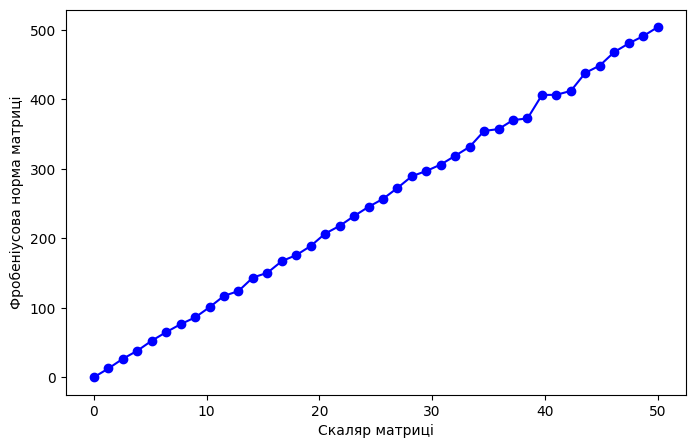

In [2]:
scalars = np.linspace(0, 50, 40)
norms = np.zeros((40,10))
for i, c in enumerate(scalars):
    for j in range(10):            
        M = np.random.randn(10, 10)   
        A = c * M                           
        norms[i, j] = np.linalg.norm(A, 'fro')  
means = norms.mean(axis=1)  

plt.figure(figsize=(8, 5))
plt.plot(scalars, means, color='blue')
plt.scatter(scalars, means, color='blue')
plt.xlabel('Скаляр матриці')
plt.ylabel('Фробеніусова норма матриці')
plt.show()

## Завдання 6.2
Знайти скаляр $s$, який зводить Фробеніусову відстань між двома випадковими матрицями до значення, меншого за 1.

In [3]:
def frobenius_distance(A, B):
    return np.linalg.norm(A - B, 'fro')

A = np.random.randn(7, 7)
B = np.random.randn(7, 7)

s = 1
iterations = 0
while frobenius_distance(s*A, s*B) > 1:
    s *= 0.9
    iterations += 1

print("Кількість ітерацій:", iterations)
print("Знайдений скаляр s:", s)
print("Фінальна Фробеніусова відстань:", frobenius_distance(s*A, s*B))


Кількість ітерацій: 22
Знайдений скаляр s: 0.0984770902183612
Фінальна Фробеніусова відстань: 0.9263890841081075


## Завдання 6.3
Продемонструйте, що метод сліду матриці та евклідова формула дають один і той самий результат (норму Фробеніуса). Чи працює формула сліду тільки для $A^{\top}A$ або чи отримуєте ви той же результат і для $AA^{\top}$?

In [4]:
A = np.array([[2.0, -1.0],
              [0.5,  3.0]])

fro_A = np.linalg.norm(A, 'fro') 
trace_ATA = np.trace(A.T @ A)
trace_AAT= np.trace(A @ A.T)  

print("Фробеніусова норма ||A1||_F =", round(fro_A,4))
print("sqrt(trace(A.T@A)) =", round(np.sqrt(trace_ATA),4))
print("sqrt(trace(A@A.T)) =", round(np.sqrt(trace_AAT)),4)
print("Формули форбеніусової норми, sqrt(A.T @ A) та sqrt(A @ A.T) рівні:", np.allclose(fro_A, np.sqrt(trace_ATA), np.sqrt(trace_AAT)))



Фробеніусова норма ||A1||_F = 3.7749
sqrt(trace(A.T@A)) = 3.7749
sqrt(trace(A@A.T)) = 4 4
Формули форбеніусової норми, sqrt(A.T @ A) та sqrt(A @ A.T) рівні: True


## Завдання 6.5
Тепер я покажу вам, як створювати випадкові матриці з довільним рангом. Для створення матриці $m\times n$ з рангом $r$ помножте випадкову матрицю $m\times r$ на матрицю $r\times n$. Реалізуйте це на Python і підтвердіть, що ранг дійсно дорівнює $r$. Що відбудеться, якщо задати $r>\min\{m,n\}$, і чому це відбувається?

In [8]:
m, n, r = 6, 8, 9
M = np.random.randn(m, r)
N = np.random.randn(r, n)
A = M @ N
rank_A = np.linalg.matrix_rank(A)
print(f"Розмір матриці M:{M.shape}")
print(f"Розмір матриці N:{N.shape}")
print(f"Розмір матриці A:{A.shape}")
print("Нерівність r>min{m,n} виконується:",r>min(m,n))

Розмір матриці M:(6, 9)
Розмір матриці N:(9, 8)
Розмір матриці A:(6, 8)
Нерівність r>min{m,n} виконується: True


## Завдання 6.6
Продемонструйте правило додавання рангу матриць $(\text{rank}(A+B) \le \text{rank}(A) + \text{rank}(B))$, створивши три пари однорангових матриць, просумованих з
1) нуль-ранговою
2) одноранговою 
3) дворанговою.

Потім повторіть цю вправу, використовуючи множення матриць замість їх додавання.

In [9]:
def create_rank_matrix(m, n, r):
    """Створюю випадкову матрицю m x n з рангом r."""
    r = min(r, min(m, n)) 
    L = np.random.randn(m, r)  # m x r
    R = np.random.randn(r, n)  # r x n
    return L @ R

In [10]:
A = create_rank_matrix(3,3,1)
rank_A = np.linalg.matrix_rank(A)

B0 = create_rank_matrix(3,3,0)                                     
B1 = create_rank_matrix(3,3,1)       
B2 = create_rank_matrix(3,3,2)     

rank_B0 = np.linalg.matrix_rank(B0)
rank_B1 = np.linalg.matrix_rank(B1)
rank_B2 = np.linalg.matrix_rank(B2)

pairs = [
    (B0, rank_B0),
    (B1, rank_B1),
    (B2, rank_B2)]

for B, rank_B in pairs:
    rank_sum = np.linalg.matrix_rank(A + B)
    sum_rank = rank_A + rank_B
    
    print(f"rankA = {rank_A}, rankB = {rank_B}")
    print(f"rankA + rankB = {rank_A + rank_B}")
    print(f"rank(A+B) = {rank_sum}")
    print(f"rank(A+B) ≤ rankA + rankВ: {rank_sum <= sum_rank}\n")
print("-"*30)
for B, rank_B in pairs:
    rank_product = np.linalg.matrix_rank(A @ B)
    max_rank = min(rank_A, rank_B)
    
    print(f"rankA = {rank_A}, rankB = {rank_B}")
    print(f"rankA @ rankB = {rank_A * rank_B}")
    print(f"rank(A@B) = {rank_product}")
    print(f"rank(A@B) ≤ rankA @ rankВ:{rank_product <= max_rank}\n")


rankA = 1, rankB = 0
rankA + rankB = 1
rank(A+B) = 1
rank(A+B) ≤ rankA + rankВ: True

rankA = 1, rankB = 1
rankA + rankB = 2
rank(A+B) = 2
rank(A+B) ≤ rankA + rankВ: True

rankA = 1, rankB = 2
rankA + rankB = 3
rank(A+B) = 3
rank(A+B) ≤ rankA + rankВ: True

------------------------------
rankA = 1, rankB = 0
rankA @ rankB = 0
rank(A@B) = 0
rank(A@B) ≤ rankA @ rankВ:True

rankA = 1, rankB = 1
rankA @ rankB = 1
rank(A@B) = 1
rank(A@B) ≤ rankA @ rankВ:True

rankA = 1, rankB = 2
rankA @ rankB = 2
rank(A@B) = 1
rank(A@B) ≤ rankA @ rankВ:True



## Завдання 6.7
Помістіть вихідний код з вправи 6.5 у функцію Python, яка на вході приймає параметри $m$ та $r$ і на виході видає випадкову матрицю $m \times m$ рангу $r$.У подвійному циклі for створіть пари матриць $20 \times 20$ з окремими рангами, що варіюються від 2 до 15. Додавайте і множте ці матриці і зберігайте ранги цих результуючих матриць. Вказані ранги повинні бути організовані в матрицю і візуалізовані як функція рангів окремих матриць.

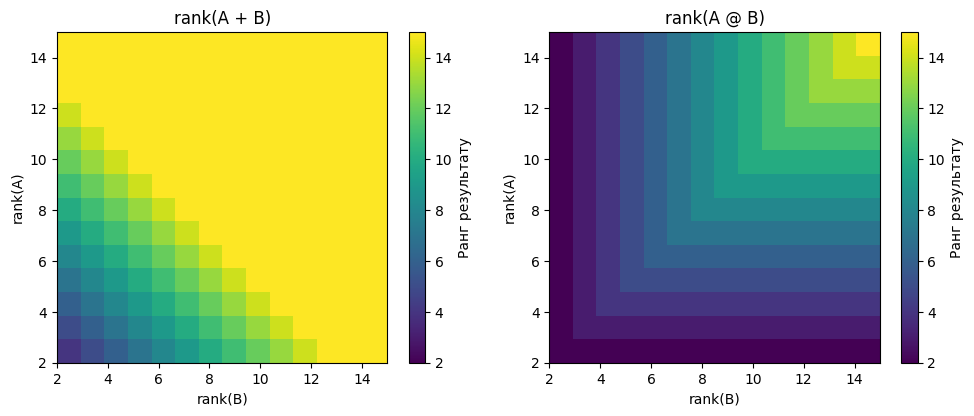

In [11]:
ranks = range(2, 16)  # ранги від 2 до 15
n = len(ranks)

rank_add = np.zeros((n, n))
rank_mult = np.zeros((n, n))

for i, r1 in enumerate(ranks):
    for j, r2 in enumerate(ranks):
        A = create_rank_matrix(20,20,r1)
        B = create_rank_matrix(20,20,r2)
        
        rank_add[i, j] = np.linalg.matrix_rank(A + B)
        rank_mult[i, j] = np.linalg.matrix_rank(A @ B)

# --- Графік 1: rank(A + B) ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rank_add, origin='lower', cmap='viridis',
           extent=[2, 15, 2, 15], vmin=2, vmax=15)
plt.title("rank(A + B)")
plt.xlabel("rank(B)")
plt.ylabel("rank(A)")
plt.colorbar(label="Ранг результату")

# --- Графік 2: rank(A @ B) ---
plt.subplot(1, 2, 2)
plt.imshow(rank_mult, origin='lower', cmap='viridis',
           extent=[2, 15, 2, 15], vmin=2, vmax=15)
plt.title("rank(A @ B)")
plt.xlabel("rank(B)")
plt.ylabel("rank(A)")
plt.colorbar(label="Ранг результату")
plt.tight_layout()
plt.show()

# Завдання 6.8
Цікаво, що всі матриці $A$, $A^\top$, $A^\top A$ і $A A^\top$ мають однаковий ранг. Напишіть вихідний код, щоб це продемонструвати, використовуючи випадкові матриці різних розмірів, контурів (квадратні, високі, широкі) та рангів.

In [12]:
def check_ranks(m, n, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    # створюємо випадкову матрицю
    A = np.random.randn(m, n)
    
    # обчислюємо всі ранги
    rank_A = np.linalg.matrix_rank(A)
    rank_AT = np.linalg.matrix_rank(A.T)
    rank_ATA = np.linalg.matrix_rank(A.T @ A)
    rank_AAT = np.linalg.matrix_rank(A @ A.T)
    
    print(f"Розмір A = {m}×{n}")
    print(f"rank(A)     = {rank_A}")
    print(f"rank(Aᵀ)    = {rank_AT}")
    print(f"rank(AᵀA)   = {rank_ATA}")
    print(f"rank(AAᵀ)   = {rank_AAT}")
    print("-" * 30)

# Квадратна матриця
check_ranks(5, 5, seed=1)

# Висока матриця 
check_ranks(8, 4, seed=2)

# Широка матриця 
check_ranks(4, 8, seed=3)


Розмір A = 5×5
rank(A)     = 5
rank(Aᵀ)    = 5
rank(AᵀA)   = 5
rank(AAᵀ)   = 5
------------------------------
Розмір A = 8×4
rank(A)     = 4
rank(Aᵀ)    = 4
rank(AᵀA)   = 4
rank(AAᵀ)   = 4
------------------------------
Розмір A = 4×8
rank(A)     = 4
rank(Aᵀ)    = 4
rank(AᵀA)   = 4
rank(AAᵀ)   = 4
------------------------------


# Завдання 6.9


In [46]:
def vector_in_column_space(A, v):
    #Перевіряє, чи вектор v належить стовпцевому простору матриці A.
    if A.shape[0] != v.shape[0]:
        raise ValueError("Розмір вектора не збігається з кількістю рядків матриці A.")
    rank_A = np.linalg.matrix_rank(A)
    rank_Av = np.linalg.matrix_rank(np.column_stack((A, v)))
    return rank_A == rank_Av

np.random.seed(0)
A = np.random.randn(4, 3)
v1 = np.random.randn(4)

print("Матриця A (4×3):\n", A)
print("Вектор v:\n", v)
print("\nЧи v ∈ C(A)? →", vector_in_column_space(A, v1))

A_full = np.random.randn(4, 4)
v2 = np.random.randn(4)

print("\nМатриця A (4×4):\n", A_full)
print("Вектор v2:\n", v2)
print("\nЧи v2 ∈ C(A)? →", vector_in_column_space(A_full, v2))


Матриця A (4×3):
 [[ 1.76405235  0.40015721  0.97873798]
 [ 2.2408932   1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721 -0.10321885]
 [ 0.4105985   0.14404357  1.45427351]]
Вектор v:
 [ 1.36453185 -0.68944918 -0.6522936  -0.52118931]

Чи v ∈ C(A)? → False

Матриця A (4×4):
 [[ 1.49407907 -0.20515826  0.3130677  -0.85409574]
 [-2.55298982  0.6536186   0.8644362  -0.74216502]
 [ 2.26975462 -1.45436567  0.04575852 -0.18718385]
 [ 1.53277921  1.46935877  0.15494743  0.37816252]]
Вектор v2:
 [-0.88778575 -1.98079647 -0.34791215  0.15634897]

Чи v2 ∈ C(A)? → True


# Завдання 6.10
Створити квадратні матриці різних розмірів, у яких два стовпці лінійно залежні, обчислити їх визначники та показати на графіку, що визначник таких (сингулярних) матриць прямує до нуля.

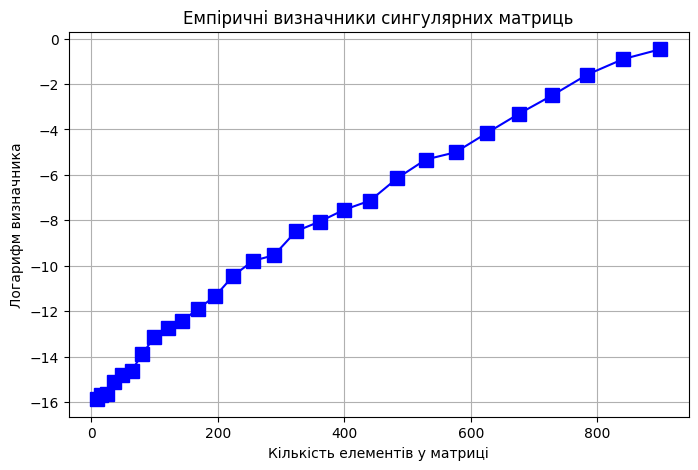

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sizes = range(3, 31)   
avg_dets = []          

for n in sizes:
    dets = []
    for _ in range(20):  
        A = np.random.randn(n, n)   
        A[:, -1] = A[:, 0]          #останній стовпець кратним першому
        det = np.linalg.det(A)      
        dets.append(abs(det))       
    avg_dets.append(np.mean(dets))  
# --- Побудова графіка ---
plt.figure(figsize=(8, 5))
plt.plot(np.array(sizes)**2, np.log10(avg_dets), color='blue', marker='s', linestyle='-', markersize=10)
plt.xlabel("Кількість елементів у матриці")
plt.ylabel("Логарифм визначника")
plt.title("Емпіричні визначники сингулярних матриць")
plt.grid(True)
plt.show()
